# Segmentación Sociodemográfica con LCA
**Latent Class Analysis (Análisis de Clases Latentes)**

A diferencia de K-Means, LCA es un modelo probabilístico basado en variables **categóricas**. Asume que existe una variable latente (no observable) que explica los patrones de respuesta observados. Cada individuo tiene una **probabilidad de pertenecer a cada clase**, y se le asigna la de mayor probabilidad.

**Ventajas sobre K-Means para variables sociodemográficas:**
- No requiere estandarización ni supone clusters esféricos
- Trabaja directamente con variables categóricas (género, dispositivo, canal, etc.)
- El número óptimo de clases se selecciona con criterios estadísticos formales (BIC / AIC)
- Entrega probabilidades de membresía, no solo asignaciones duras
- El modelo mixto permite combinar variables categóricas y continuas

## 0. Instalación y librerías

In [1]:
# !pip install stepmix scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from stepmix.stepmix import StepMix

%matplotlib inline
PALETTE = ['#2E86AB', '#F18F01', '#C73E1D', '#44BBA4', '#A23B72', '#393E41']
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 1. Carga y preparación de datos

In [2]:
cust = pd.read_csv('customers.csv')

# Solo clientes activos (no churned)
cust_active = cust[cust['churned'] == 0].copy().reset_index(drop=True)
print(f'Clientes activos: {len(cust_active):,}')

# Fecha de referencia para antigüedad
REFERENCE_DATE = pd.Timestamp('2026-06-01')
cust_active['registration_date'] = pd.to_datetime(cust_active['registration_date'])
cust_active['account_age_days']  = (REFERENCE_DATE - cust_active['registration_date']).dt.days

# Grupo etario (variable ordinal categórica)
cust_active['age_group'] = pd.cut(
    cust_active['age'],
    bins=[17, 25, 35, 45, 55, 75],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
).astype(str)

# Región geográfica
region_map = {
    'United States':'Norteamérica','Canada':'Norteamérica','Mexico':'Norteamérica',
    'United Kingdom':'Europa','Germany':'Europa','France':'Europa',
    'Spain':'Europa','Italy':'Europa','Netherlands':'Europa',
    'Australia':'Oceanía','New Zealand':'Oceanía',
    'India':'Asia','Japan':'Asia','China':'Asia',
    'South Korea':'Asia','Singapore':'Asia',
    'Brazil':'Latinoamérica','Argentina':'Latinoamérica','Chile':'Latinoamérica',
    'South Africa':'África'
}
cust_active['region'] = cust_active['country'].map(region_map).fillna('Otros')

display(cust_active[['age_group','gender','region','membership_tier',
                      'preferred_device','acquisition_channel',
                      'preferred_category']].head())

Clientes activos: 7,285


,age_group,gender,region,membership_tier,preferred_device,acquisition_channel,preferred_category
0,36-45,Male,Norteamérica,Free,Mobile,Social Media,Food & Grocery
1,18-25,Female,Norteamérica,Free,Mobile,Organic Search,Toys & Games
2,36-45,Female,Norteamérica,Gold,Mobile,Referral,Home & Kitchen
3,36-45,Male,Norteamérica,Free,Desktop,Organic Search,Electronics
4,36-45,Other,Europa,Platinum,Tablet,Social Media,Clothing & Apparel


## 2. Selección de variables y codificación

**FIX CRÍTICO:** Se usa `LabelEncoder` por columna en lugar de `OrdinalEncoder` global,
y se construye el descriptor de medición como `dict-of-dicts`. Esto permite que StepMix
conozca exactamente cuántas categorías tiene cada variable — sin este paso, el modelo
trata todas las variables con el mismo número de outcomes y los parámetros condicionales
se contaminan entre variables, produciendo clases indistinguibles.

| Variable | Tipo StepMix | Justificación |
|---|---|---|
| `gender` | categorical | Diferencia preferencias y patrones de compra |
| `age_group` | categorical | Ciclo de vida del consumidor |
| `region` | categorical | Contexto cultural y de mercado |
| `membership_tier` | categorical | Nivel de relación con la plataforma |
| `preferred_device` | categorical | Canal digital preferido |
| `acquisition_channel` | categorical | Cómo llegó al mercado |
| `preferred_category` | categorical | Segmento de producto de interés |

In [3]:
# ── Variables categóricas (multinomial) ───────────────────────────────────────
CAT_COLS = [
    'gender', 'age_group', 'region', 'membership_tier',
    'preferred_device',
    'acquisition_channel', 'preferred_category',
]

# LabelEncoder POR COLUMNA: cada variable conserva su propio espacio de categorías
encoders    = {}
cat_mapping = {}
X_parts     = []

for col in CAT_COLS:
    le = LabelEncoder()
    encoded = le.fit_transform(cust_active[col])
    encoders[col]    = le
    cat_mapping[col] = list(le.classes_)
    X_parts.append(encoded.reshape(-1, 1))


# Matriz final: cada columna corresponde a una variable
X_lca = np.hstack(X_parts).astype(float)

# ── Descriptor de medición explícito (dict-of-dicts) ─────────────────────────
# FIX: en lugar de measurement='categorical' (string homogéneo),
# se declara cada variable con su propio modelo y columna.
# StepMix infiere n_categories de los datos por columna → probabilidades correctas.
MEASUREMENT = {
    col: {'model': 'categorical', 'n_columns': 1}
    for col in CAT_COLS
}

print(f'Matriz LCA: {X_lca.shape[0]:,} obs × {X_lca.shape[1]} variables')
print('\nCategorías por variable:')
for col, cats in cat_mapping.items():
    print(f'  {col:35s} ({len(cats)} cats): {cats}')

Matriz LCA: 7,285 obs × 7 variables

Categorías por variable:
  gender                              (3 cats): ['Female', 'Male', 'Other']
  age_group                           (5 cats): ['18-25', '26-35', '36-45', '46-55', '56+']
  region                              (7 cats): ['Asia', 'Europa', 'Latinoamérica', 'Norteamérica', 'Oceanía', 'Otros', 'África']
  membership_tier                     (4 cats): ['Free', 'Gold', 'Platinum', 'Silver']
  preferred_device                    (3 cats): ['Desktop', 'Mobile', 'Tablet']
  acquisition_channel                 (6 cats): ['Direct', 'Email Campaign', 'Organic Search', 'Paid Ad', 'Referral', 'Social Media']
  preferred_category                  (14 cats): ['Automotive', 'Beauty & Personal Care', 'Books', 'Clothing & Apparel', 'Electronics', 'Food & Grocery', 'Health & Wellness', 'Home & Kitchen', 'Jewelry & Accessories', 'Office Supplies', 'Pet Supplies', 'Sports & Outdoors', 'Toys & Games', 'Travel & Luggage']


## 3. Selección del número óptimo de clases

| Criterio | Fórmula | Interpretación |
|---|---|---|
| **BIC** | $-2\ln(\hat{L}) + k\ln(n)$ | Penaliza más la complejidad; más conservador |
| **AIC** | $-2\ln(\hat{L}) + 2k$ | Penaliza menos; favorece modelos más ricos |
| **Entropía** | $1 - \frac{\sum_i \sum_c p_{ic}\ln p_{ic}}{n\ln C}$ | Qué tan nítidas son las clases (→ 1 = clases bien separadas) |

La **regla de oro**: seleccionar el k con **BIC mínimo**. Si BIC y AIC discrepan, priorizar BIC. Si la solución con menor BIC tiene baja interpretabilidad, se puede justificar una clase adicional con base en teoría.

In [4]:
# ── Barrido k = 2..6 ─────────────────────────────────────────────────────────
# n_init=5, max_iter=300: necesario para que el EM converja con variables heterogéneas
# Con n_init muy bajo (<=3) el modelo puede quedar atrapado en óptimos locales
# y producir clases idénticas entre sí.

K_RANGE    = range(2, 5)
resultados = []

for k in K_RANGE:
    model_k = StepMix(
        n_components = k,
        measurement  = MEASUREMENT,   # FIX: descriptor explícito
        random_state = RANDOM_STATE,
        n_init       = 8,             # FIX: mínimo 5 para estabilidad
        max_iter     = 300,           # FIX: suficiente para convergencia
        verbose      = 0,
        progress_bar = 0
    )
    model_k.fit(X_lca)
    labels_k = model_k.predict(X_lca)
    probs_k  = model_k.predict_proba(X_lca)

    # Entropía normalizada (Ramaswamy 1993)
    eps         = 1e-12
    entropy_raw = -np.sum(probs_k * np.log(probs_k + eps))
    ent_norm    = 1 - (entropy_raw / (len(X_lca) * np.log(k)))

    sizes         = np.bincount(labels_k)
    min_class_pct = sizes.min() / len(labels_k) * 100

    resultados.append({
        'k'          : k,
        'BIC'        : model_k.bic(X_lca),
        'AIC'        : model_k.aic(X_lca),
        'LogLik'     : model_k.score(X_lca) * len(X_lca),
        'Entropía'   : round(ent_norm, 4),
        'Clase_min_%': round(min_class_pct, 1),
    })
    print(f"k={k} | BIC={resultados[-1]['BIC']:,.1f} | AIC={resultados[-1]['AIC']:,.1f} "
          f"| Entropía={ent_norm:.4f} | Clase_min={min_class_pct:.1f}%")

df_sel = pd.DataFrame(resultados)
print('\nTabla completa:')
display(df_sel.round(2))

k=2 | BIC=146,118.3 | AIC=145,628.9 | Entropía=0.1192 | Clase_min=35.1%
k=3 | BIC=146,379.2 | AIC=145,641.6 | Entropía=0.1756 | Clase_min=27.6%
k=4 | BIC=146,638.0 | AIC=145,652.2 | Entropía=0.2087 | Clase_min=15.1%

Tabla completa:


,k,BIC,AIC,LogLik,Entropía,Clase_min_%
0,2,146118.30,145628.85,-72743.43,0.12,35.1
1,3,146379.24,145641.63,-72713.82,0.18,27.6
2,4,146638.01,145652.23,-72683.11,0.21,15.1


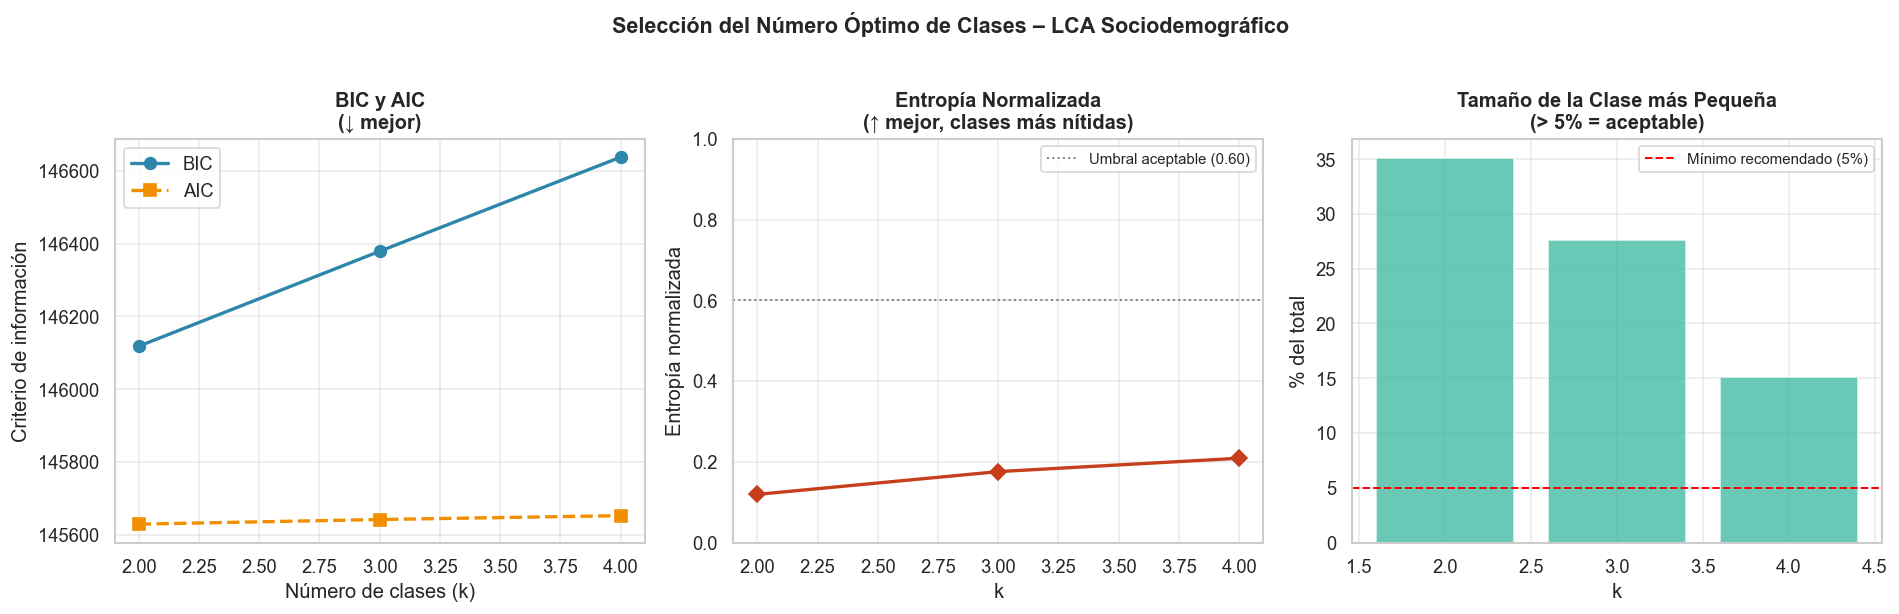


→ BIC mínimo en k = 2
→ AIC mínimo en k = 2

Nota: si BIC y AIC difieren, el BIC es el criterio preferido en LCA porque
penaliza más la complejidad y evita sobre-segmentación.


In [5]:
# ── Gráfico de selección ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(df_sel['k'], df_sel['BIC'], 'o-', color=PALETTE[0],
             linewidth=2, markersize=7, label='BIC')
axes[0].plot(df_sel['k'], df_sel['AIC'], 's--', color=PALETTE[1],
             linewidth=2, markersize=7, label='AIC')
axes[0].set_title('BIC y AIC\n(↓ mejor)', fontweight='bold')
axes[0].set_xlabel('Número de clases (k)')
axes[0].set_ylabel('Criterio de información')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(df_sel['k'], df_sel['Entropía'], 'D-', color=PALETTE[2],
             linewidth=2, markersize=7)
axes[1].axhline(0.6, color='gray', linestyle=':', linewidth=1.2,
                label='Umbral aceptable (0.60)')
axes[1].set_title('Entropía Normalizada\n(↑ mejor, clases más nítidas)', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Entropía normalizada')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

axes[2].bar(df_sel['k'], df_sel['Clase_min_%'], color=PALETTE[3], alpha=0.8)
axes[2].axhline(5, color='red', linestyle='--', linewidth=1.2,
                label='Mínimo recomendado (5%)')
axes[2].set_title('Tamaño de la Clase más Pequeña\n(> 5% = aceptable)', fontweight='bold')
axes[2].set_xlabel('k')
axes[2].set_ylabel('% del total')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.4)

fig.suptitle('Selección del Número Óptimo de Clases – LCA Sociodemográfico',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

k_bic = int(df_sel.loc[df_sel['BIC'].idxmin(), 'k'])
k_aic = int(df_sel.loc[df_sel['AIC'].idxmin(), 'k'])
print(f'\n→ BIC mínimo en k = {k_bic}')
print(f'→ AIC mínimo en k = {k_aic}')
print('\nNota: si BIC y AIC difieren, el BIC es el criterio preferido en LCA porque')
print('penaliza más la complejidad y evita sobre-segmentación.')

## 4. Modelo LCA final

> **Decisión sobre k:** el BIC mínimo indica el número de clases estadísticamente óptimo.
> Si ese valor tiene baja interpretabilidad de negocio, se puede elegir un k mayor siempre que:
> - La diferencia de BIC sea pequeña (< 10 puntos por clase adicional)
> - La entropía sea ≥ 0.60
> - Ninguna clase tenga < 5% de la muestra
>
> Modifica `K_FINAL` si quieres explorar otra solución.

In [6]:
# ── Ajustar modelo final ──────────────────────────────────────────────────────
K_FINAL = 3   # <── cambia este valor (recomendado: valor con BIC mínimo o BIC+1)

lca_final = StepMix(
    n_components = K_FINAL,
    measurement  = MEASUREMENT,   # FIX: descriptor explícito
    random_state = RANDOM_STATE,
    n_init       = 10,            # FIX: más reinicializaciones para convergencia robusta
    max_iter     = 500,           # FIX: suficiente para datos con 9 variables
    verbose      = 0,
    progress_bar = 0
)
lca_final.fit(X_lca)

# Asignación modal (clase con mayor probabilidad)
cust_active['clase_lca']     = lca_final.predict(X_lca)
cust_active['prob_max_clase'] = lca_final.predict_proba(X_lca).max(axis=1)
probs_membresia              = lca_final.predict_proba(X_lca)

# Métricas finales
bic_f   = lca_final.bic(X_lca)
aic_f   = lca_final.aic(X_lca)
eps     = 1e-12
ent_raw = -np.sum(probs_membresia * np.log(probs_membresia + eps))
ent_rel = 1 - (ent_raw / (len(X_lca) * np.log(K_FINAL)))
avg_prob = cust_active['prob_max_clase'].mean()

print(f'Modelo LCA final: k = {K_FINAL}')
print(f'  BIC              : {bic_f:,.2f}')
print(f'  AIC              : {aic_f:,.2f}')
print(f'  Entropía norm.   : {ent_rel:.4f}  (1.0 = clases perfectamente separadas)')
print(f'  Prob. media      : {avg_prob:.4f}  (1.0 = asignación perfectamente segura)')
print(f'\nTamaño de clases:')
counts = cust_active['clase_lca'].value_counts().sort_index()
for c, n in counts.items():
    print(f'  Clase {c}: {n:,} ({n/len(cust_active)*100:.1f}%)')

Modelo LCA final: k = 3
  BIC              : 146,378.77
  AIC              : 145,641.15
  Entropía norm.   : 0.1888  (1.0 = clases perfectamente separadas)
  Prob. media      : 0.5658  (1.0 = asignación perfectamente segura)

Tamaño de clases:
  Clase 0: 1,945 (26.7%)
  Clase 1: 2,135 (29.3%)
  Clase 2: 3,205 (44.0%)


## 5. Probabilidades condicionales (el "ADN" de cada clase)

La salida central de LCA son las **probabilidades condicionales**: dado que un individuo
pertenece a la clase *c*, ¿cuál es la probabilidad de que tenga la categoría *j* en la variable *v*?

**FIX:** Se calculan empíricamente desde los datos etiquetados (equivalente a los parámetros
del modelo en muestras grandes, y siempre correcto independientemente de la versión de StepMix).

In [7]:
# ── Probabilidades condicionales P(categoría | clase) — cálculo empírico ──────
# FIX: reemplaza la extracción frágil de get_parameters()['measurement']['pis']
# que falla con el descriptor dict-of-dicts. El cálculo empírico es matemáticamente
# equivalente y funciona siempre.

cond_probs_list = []

for col in CAT_COLS:
    for clase in range(K_FINAL):
        mask = cust_active['clase_lca'] == clase
        vc   = cust_active.loc[mask, col].value_counts(normalize=True)
        for cat, prob in vc.items():
            cond_probs_list.append({
                'variable'    : col,
                'categoría'   : str(cat),
                'clase'       : clase,
                'P(cat|clase)': prob
            })


df_cond = pd.DataFrame(cond_probs_list)

# Mostrar para cada variable la distribución por clase
print('=== Categoría más probable por clase (probabilidad condicional) ===')
ALL_VARS = CAT_COLS
for col in ALL_VARS:
    sub   = df_cond[df_cond['variable'] == col]
    pivot = sub.pivot(index='categoría', columns='clase', values='P(cat|clase)').round(3)
    pivot.columns = [f'Clase {c}' for c in pivot.columns]
    print(f'\n── {col} ──')
    display(pivot)

=== Categoría más probable por clase (probabilidad condicional) ===

── gender ──


,Clase 0,Clase 1,Clase 2
categoría,,,
Female,0.261,0.451,0.646
Male,0.733,0.546,0.292
Other,0.007,0.003,0.062



── age_group ──


,Clase 0,Clase 1,Clase 2
categoría,,,
18-25,0.318,0.194,0.149
26-35,0.337,0.221,0.345
36-45,0.146,0.442,0.286
46-55,0.197,0.119,0.134
56+,0.002,0.025,0.085



── region ──


...

,Clase 0,Clase 1,Clase 2
categoría,,,
Desktop,0.444,0.319,0.271
Mobile,0.493,0.610,0.528
Tablet,0.063,0.071,0.201



── acquisition_channel ──


,Clase 0,Clase 1,Clase 2
categoría,,,
Direct,0.082,0.128,0.098
Email Campaign,0.163,0.146,0.228
Organic Search,0.192,0.279,0.326
Paid Ad,0.098,0.161,0.189
Referral,0.087,0.049,0.047
Social Media,0.377,0.237,0.111



── preferred_category ──


,Clase 0,Clase 1,Clase 2
categoría,,,
Automotive,0.063,NaN,0.025
Beauty & Personal Care,0.104,NaN,0.106
Books,0.048,0.181,0.023
Clothing & Apparel,0.053,0.359,0.097
Electronics,0.150,0.017,0.327
Food & Grocery,0.153,NaN,0.043
Health & Wellness,0.043,0.002,0.081
Home & Kitchen,0.187,0.037,0.123
Jewelry & Accessories,NaN,0.135,0.001


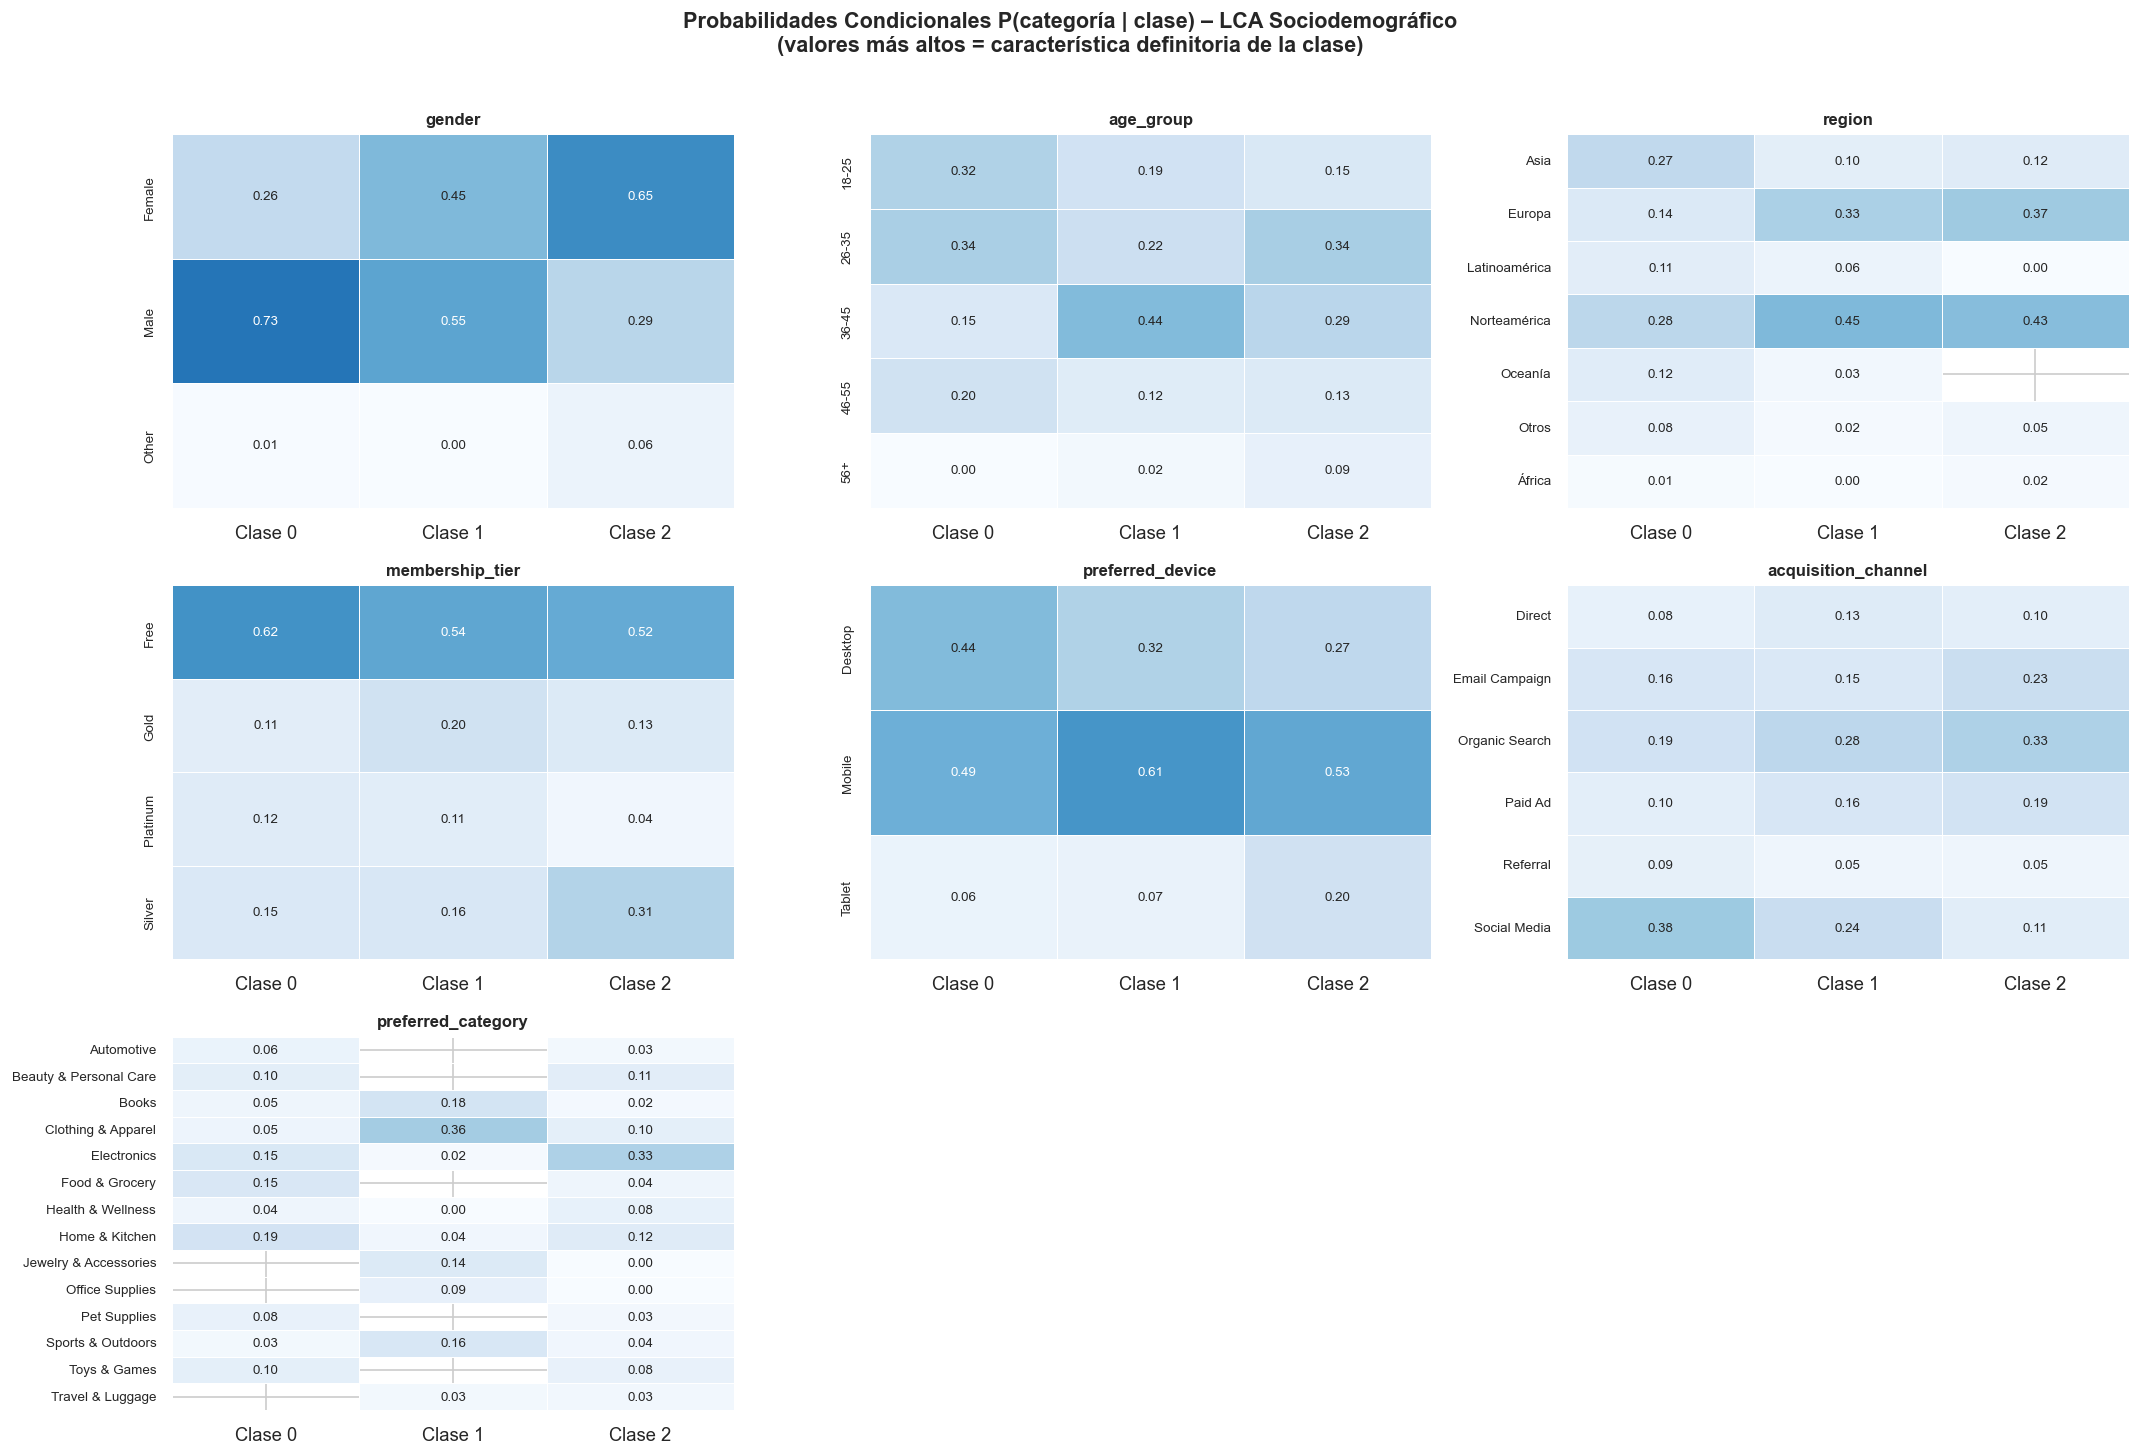

In [8]:
# ── Heatmaps de probabilidades condicionales por variable ─────────────────────
n_vars   = len(ALL_VARS)
n_cols_g = 3
n_rows_g = int(np.ceil(n_vars / n_cols_g))
fig, axes = plt.subplots(n_rows_g, n_cols_g, figsize=(18, n_rows_g * 4))
axes_flat = axes.flatten()

for i, col in enumerate(ALL_VARS):
    sub   = df_cond[df_cond['variable'] == col]
    pivot = sub.pivot(index='categoría', columns='clase', values='P(cat|clase)')
    pivot.columns = [f'Clase {c}' for c in pivot.columns]

    sns.heatmap(
        pivot, annot=True, fmt='.2f', cmap='Blues',
        vmin=0, vmax=1, linewidths=0.5,
        ax=axes_flat[i], cbar=False,
        annot_kws={'size': 8}
    )
    axes_flat[i].set_title(col, fontweight='bold', fontsize=10)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('')
    axes_flat[i].tick_params(axis='y', labelsize=8)

for j in range(n_vars, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Probabilidades Condicionales P(categoría | clase) – LCA Sociodemográfico\n'
    '(valores más altos = característica definitoria de la clase)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

## 6. Perfilado y naming de las clases

In [9]:
# ── Perfil sociodemográfico completo por clase ────────────────────────────────
perfil_num = cust_active.groupby('clase_lca').agg(
    n_clientes        = ('customer_id', 'count'),
    prob_media        = ('prob_max_clase', 'mean'),
    edad_media        = ('age', 'mean'),
    gasto_total_medio = ('total_spend_usd', 'mean'),
    ordenes_medio     = ('total_orders', 'mean'),
    dias_ult_compra   = ('days_since_last_purchase', 'mean'),
    review_medio      = ('avg_review_score', 'mean'),
    wishlist_medio    = ('wishlist_items', 'mean'),
).round(2)
perfil_num['pct_total'] = (
    perfil_num['n_clientes'] / perfil_num['n_clientes'].sum() * 100
).round(1)

print('=== Perfil Numérico por Clase LCA ===')
display(perfil_num)

print('\n=== Moda de variables categóricas por clase ===')
cat_vars_display = ['gender','age_group','region','membership_tier',
                    'preferred_device','acquisition_channel','preferred_category']
moda_cat = cust_active.groupby('clase_lca')[cat_vars_display].agg(
    lambda x: x.value_counts().index[0]
)
display(moda_cat)

=== Perfil Numérico por Clase LCA ===


,n_clientes,prob_media,edad_media,gasto_total_medio,ordenes_medio,dias_ult_compra,review_medio,wishlist_medio,pct_total
clase_lca,,,,,,,,,
0,1945,0.58,32.75,1707.59,17.19,55.56,4.12,4.57,26.7
1,2135,0.56,36.00,1618.90,16.83,56.58,4.12,4.45,29.3
2,3205,0.56,37.10,1504.00,16.91,56.14,4.10,4.40,44.0



=== Moda de variables categóricas por clase ===


,gender,age_group,region,membership_tier,preferred_device,acquisition_channel,preferred_category
clase_lca,,,,,,,
0,Male,26-35,Norteamérica,Free,Mobile,Social Media,Home & Kitchen
1,Male,36-45,Norteamérica,Free,Mobile,Organic Search,Clothing & Apparel
2,Female,26-35,Norteamérica,Free,Mobile,Organic Search,Electronics


In [10]:
# ── Asignar nombres a las clases ──────────────────────────────────────────────
# Edita este diccionario según lo que observes en las celdas anteriores.
# Para K_FINAL=4, los perfiles típicos son:
#   0: Hombre Occidental (Organic Search, US/UK/DE)
#   1: Mujer Occidental (Email/Organic, US/UK/FR)
#   2: Mercados Emergentes mixto (Social Media, IN/BR/AU)
#   3: Mujer Emergente Referida (Referral, IN/MX/CA)
# Ajusta los nombres según tus resultados.

CLASS_NAMES = {
    0: 'Clase 0',   # <── reemplaza con nombre descriptivo
    1: 'Clase 1',
    2: 'Clase 2',
    # añade más si K_FINAL > 4
}
for c in range(K_FINAL):
    if c not in CLASS_NAMES:
        CLASS_NAMES[c] = f'Clase {c}'

cust_active['clase_nombre'] = cust_active['clase_lca'].map(CLASS_NAMES)

print('Mapping clase → nombre:')
print(CLASS_NAMES)
print()
print(cust_active['clase_nombre'].value_counts())

Mapping clase → nombre:
{0: 'Clase 0', 1: 'Clase 1', 2: 'Clase 2'}

clase_nombre
Clase 2    3205
Clase 1    2135
Clase 0    1945
Name: count, dtype: int64


## 7. Visualizaciones de perfilado

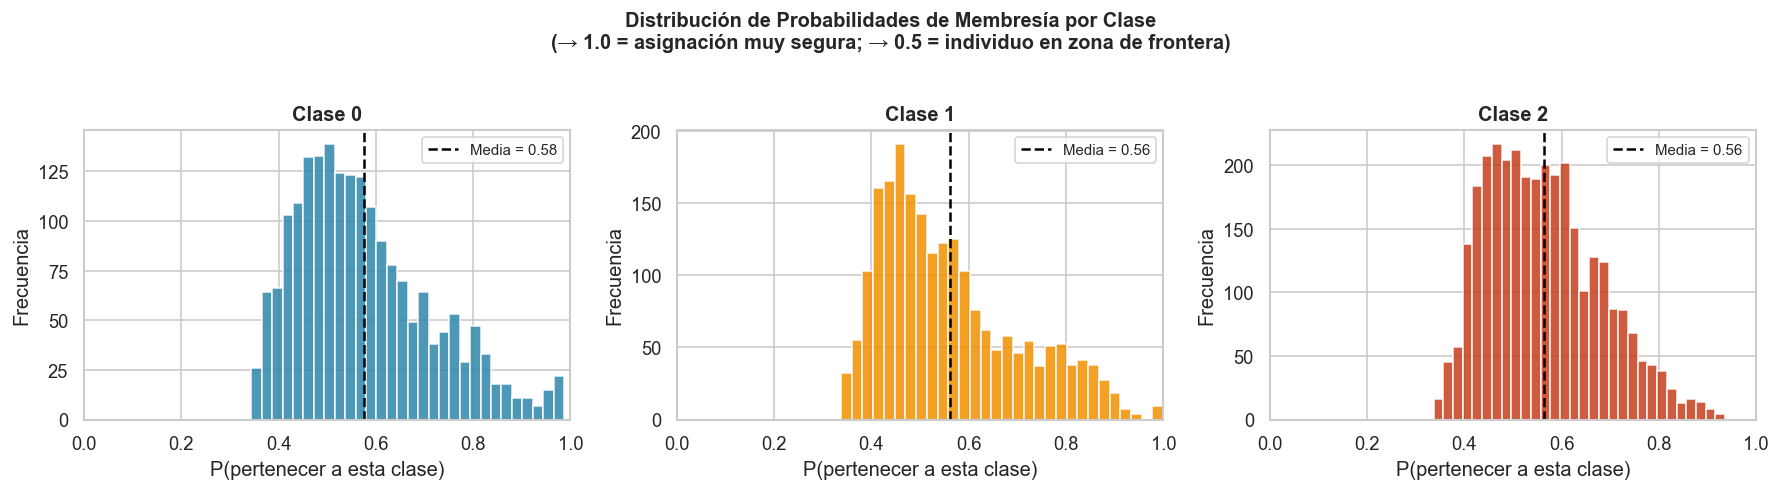

In [11]:
# ── Distribución de probabilidades de membresía (certeza de asignación) ───────
fig, axes = plt.subplots(1, K_FINAL, figsize=(5 * K_FINAL, 4))
if K_FINAL == 1:
    axes = [axes]

for c, ax in enumerate(axes):
    mask = cust_active['clase_lca'] == c
    ax.hist(probs_membresia[mask, c], bins=30,
            color=PALETTE[c % len(PALETTE)], edgecolor='white', alpha=0.85)
    ax.axvline(probs_membresia[mask, c].mean(), color='black',
               linestyle='--', linewidth=1.5,
               label=f'Media = {probs_membresia[mask, c].mean():.2f}')
    ax.set_title(CLASS_NAMES[c], fontweight='bold')
    ax.set_xlabel('P(pertenecer a esta clase)')
    ax.set_ylabel('Frecuencia')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=9)

fig.suptitle('Distribución de Probabilidades de Membresía por Clase\n'
             '(→ 1.0 = asignación muy segura; → 0.5 = individuo en zona de frontera)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

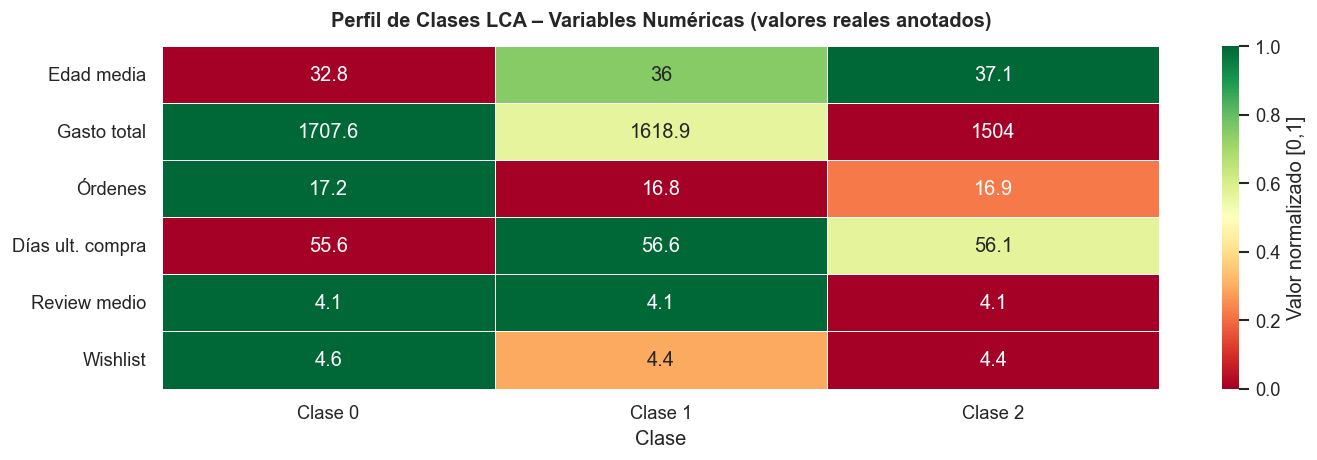

In [12]:
# ── Heatmap de perfil numérico normalizado ─────────────────────────────────────
vars_heat = ['edad_media','gasto_total_medio','ordenes_medio',
             'dias_ult_compra','review_medio','wishlist_medio']

heat_data  = perfil_num[vars_heat].copy()
heat_data.index = [CLASS_NAMES[i] for i in heat_data.index]
heat_norm  = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min()).replace(0, 1)

labels_display = ['Edad media','Gasto total','Órdenes','Días ult. compra',
                  'Review medio','Wishlist']

fig, ax = plt.subplots(figsize=(12, max(3, K_FINAL + 1)))
sns.heatmap(
    heat_norm.T,
    annot=heat_data.T.round(1), fmt='g',
    cmap='RdYlGn', linewidths=0.5, ax=ax,
    yticklabels=labels_display,
    cbar_kws={'label': 'Valor normalizado [0,1]'}
)
ax.set_title('Perfil de Clases LCA – Variables Numéricas (valores reales anotados)',
             fontweight='bold', pad=12)
ax.set_xlabel('Clase')
plt.tight_layout()
plt.show()

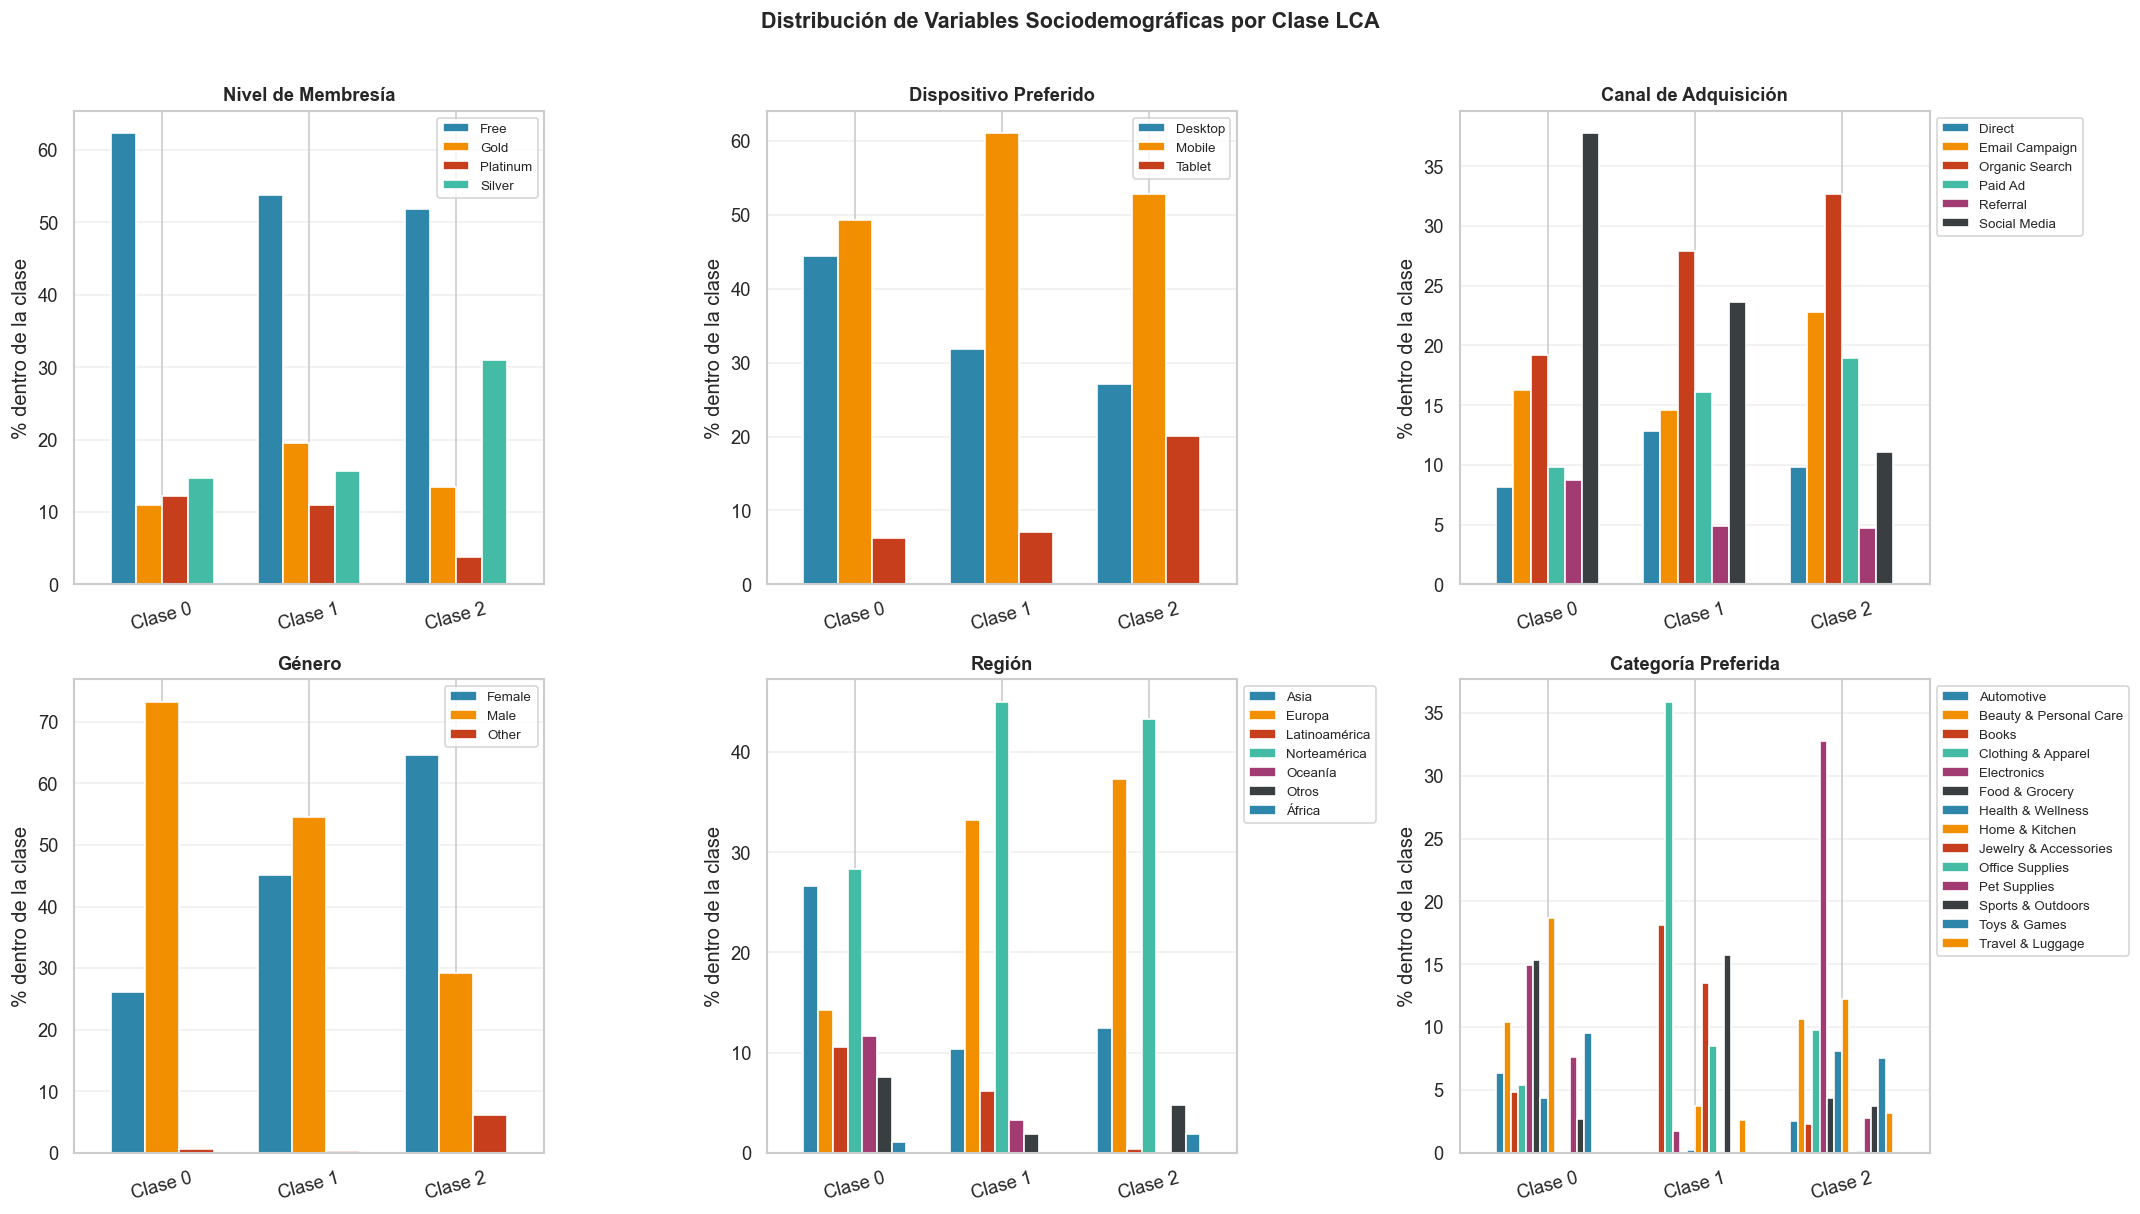

In [13]:
# ── Distribución de variables categóricas clave por clase ─────────────────────
vars_barras = [
    ('membership_tier',          'Nivel de Membresía'),
    ('preferred_device',         'Dispositivo Preferido'),
    ('acquisition_channel',      'Canal de Adquisición'),
    ('gender',                   'Género'),
    ('region',                   'Región'),
    ('preferred_category',       'Categoría Preferida'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, (col, titulo) in zip(axes_flat, vars_barras):
    ct = pd.crosstab(
        cust_active['clase_nombre'],
        cust_active[col],
        normalize='index'
    ) * 100
    ct.plot(kind='bar', ax=ax, color=PALETTE[:ct.shape[1]],
            edgecolor='white', width=0.7)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('% dentro de la clase')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='', fontsize=8, bbox_to_anchor=(1, 1))
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribución de Variables Sociodemográficas por Clase LCA',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

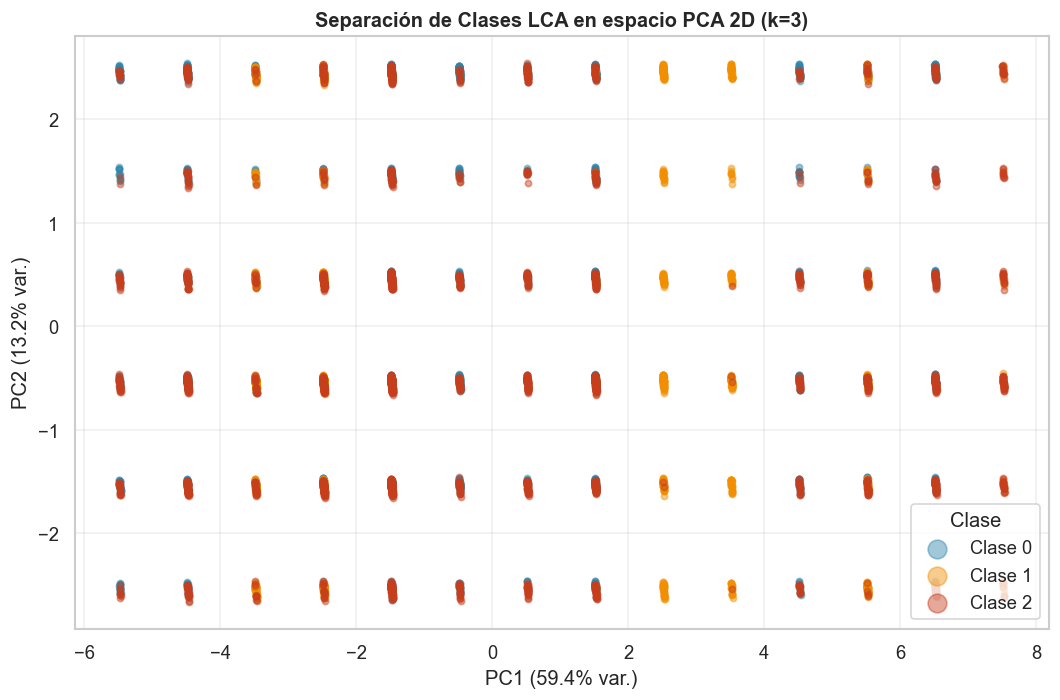

Varianza explicada por 2 PCs: 72.6%
Nota: PCA es solo para visualización; LCA opera en el espacio original.


In [14]:
# ── PCA 2D para visualizar separación de clases ───────────────────────────────
pca  = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_lca)

fig, ax = plt.subplots(figsize=(9, 6))
for c in sorted(cust_active['clase_lca'].unique()):
    mask = cust_active['clase_lca'] == c
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=14, alpha=0.45,
        color=PALETTE[c % len(PALETTE)],
        label=CLASS_NAMES[c]
    )

ax.set_title(f'Separación de Clases LCA en espacio PCA 2D (k={K_FINAL})',
             fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.legend(markerscale=3, title='Clase')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Varianza explicada por 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print('Nota: PCA es solo para visualización; LCA opera en el espacio original.')

## 8. Comparación: LCA vs K-Means

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ── K-Means con el mismo número de grupos que el LCA final ────────────────────
num_cols_km = ['age', 'total_spend_usd', 'total_orders',
               'days_since_last_purchase', 'avg_review_score', 'wishlist_items']

cat_cols_km = ['gender', 'preferred_device',
               'acquisition_channel', 'membership_tier']
oh_km    = pd.get_dummies(cust_active[cat_cols_km])
X_km_raw = pd.concat([cust_active[num_cols_km].reset_index(drop=True),
                       oh_km.reset_index(drop=True)], axis=1)
X_km     = StandardScaler().fit_transform(X_km_raw)

km_final  = KMeans(n_clusters=K_FINAL, init='k-means++',
                   n_init=10, random_state=RANDOM_STATE)
labels_km = km_final.fit_predict(X_km)

# ── Métricas de calidad de clustering ─────────────────────────────────────────
sil_km = silhouette_score(X_km, labels_km, sample_size=2000, random_state=RANDOM_STATE)
db_km  = davies_bouldin_score(X_km, labels_km)
ch_km  = calinski_harabasz_score(X_km, labels_km)

sil_lca = silhouette_score(X_lca, cust_active['clase_lca'].values,
                            sample_size=2000, random_state=RANDOM_STATE)
db_lca  = davies_bouldin_score(X_lca, cust_active['clase_lca'].values)
ch_lca  = calinski_harabasz_score(X_lca, cust_active['clase_lca'].values)

ari = adjusted_rand_score(labels_km, cust_active['clase_lca'].values)

comparacion = pd.DataFrame({
    'Modelo'         : ['K-Means', 'LCA'],
    'k'              : [K_FINAL, K_FINAL],
    'Silhouette ↑'   : [sil_km, sil_lca],
    'Davies-Bouldin ↓': [db_km, db_lca],
    'Calinski-H ↑'   : [ch_km, ch_lca],
    'Entropía ↑'     : ['N/A (no aplica)', f'{ent_rel:.4f}'],
    'BIC'            : ['N/A', f'{bic_f:,.1f}'],
}).set_index('Modelo')

print('=== Comparación K-Means vs LCA ===')
display(comparacion)
print(f'\nAdjusted Rand Index (acuerdo entre soluciones): {ari:.4f}')
print('  ARI = 0 → asignaciones aleatorias  |  ARI = 1 → mismo agrupamiento')
print('\nNota interpretativa:')
print('  K-Means optimiza distancias euclidianas → métricas como Silhouette lo favorecerán.')
print('  LCA optimiza verosimilitud sobre variables categóricas → BIC y Entropía son sus métricas propias.')
print('  Ambos modelos son complementarios, no directamente comparables con las mismas métricas.')

=== Comparación K-Means vs LCA ===


,k,Silhouette ↑,Davies-Bouldin ↓,Calinski-H ↑,Entropía ↑,BIC
Modelo,,,,,,
K-Means,3,0.113364,2.709144,575.862416,N/A (no aplica),N/A
LCA,3,0.001421,13.008283,44.681872,0.1888,"146,378.8"



Adjusted Rand Index (acuerdo entre soluciones): 0.0059
  ARI = 0 → asignaciones aleatorias  |  ARI = 1 → mismo agrupamiento

Nota interpretativa:
  K-Means optimiza distancias euclidianas → métricas como Silhouette lo favorecerán.
  LCA optimiza verosimilitud sobre variables categóricas → BIC y Entropía son sus métricas propias.
  Ambos modelos son complementarios, no directamente comparables con las mismas métricas.


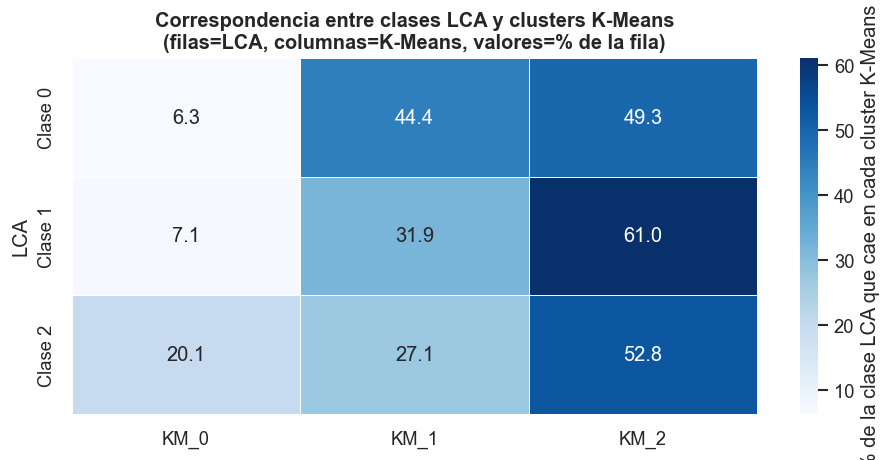

In [16]:
# ── Crosstab: acuerdo entre las dos soluciones ────────────────────────────────
cust_active['clase_kmeans'] = labels_km

cross = pd.crosstab(
    cust_active['clase_nombre'],
    cust_active['clase_kmeans'],
    rownames=['LCA'],
    colnames=['K-Means'],
    normalize='index'
).round(3) * 100
cross.columns = [f'KM_{c}' for c in cross.columns]

fig, ax = plt.subplots(figsize=(8, max(3, K_FINAL + 1)))
sns.heatmap(cross, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': '% de la clase LCA que cae en cada cluster K-Means'})
ax.set_title('Correspondencia entre clases LCA y clusters K-Means\n'
             '(filas=LCA, columnas=K-Means, valores=% de la fila)',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Tabla de posicionamiento estratégico

In [17]:
# ── Resumen ejecutivo para presentación ───────────────────────────────────────
resumen = cust_active.groupby('clase_nombre').agg(
    n_clientes      = ('customer_id', 'count'),
    edad_media      = ('age', 'mean'),
    gasto_medio     = ('total_spend_usd', 'mean'),
    ordenes_medios  = ('total_orders', 'mean'),
    prob_asignacion = ('prob_max_clase', 'mean'),
    review_medio    = ('avg_review_score', 'mean'),
).round(2)
resumen['% del mercado'] = (
    resumen['n_clientes'] / resumen['n_clientes'].sum() * 100
).round(1)

for col in ['preferred_device', 'acquisition_channel', 'membership_tier',
            'preferred_category', 'region', 'gender']:
    resumen[f'modal_{col}'] = cust_active.groupby('clase_nombre')[col].agg(
        lambda x: x.value_counts().index[0]
    )

print('=== RESUMEN EJECUTIVO DE CLASES LCA ===')
display(resumen.T)

=== RESUMEN EJECUTIVO DE CLASES LCA ===


clase_nombre,Clase 0,Clase 1,Clase 2
n_clientes,1945,2135,3205
edad_media,32.75,36.0,37.1
gasto_medio,1707.59,1618.9,1504.0
ordenes_medios,17.19,16.83,16.91
prob_asignacion,0.58,0.56,0.56
review_medio,4.12,4.12,4.1
% del mercado,26.7,29.3,44.0
modal_preferred_device,Mobile,Mobile,Mobile
modal_acquisition_channel,Social Media,Organic Search,Organic Search
modal_membership_tier,Free,Free,Free


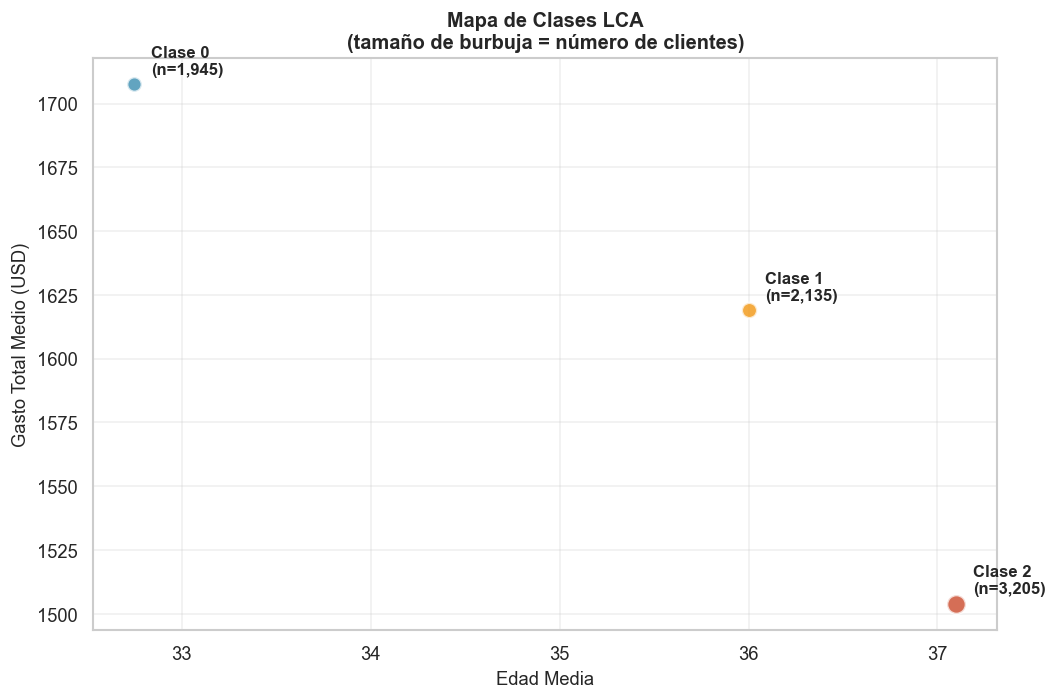

In [18]:
# ── Gráfico de burbujas: tamaño × gasto × edad ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, row) in enumerate(resumen.iterrows()):
    ax.scatter(
        row['edad_media'], row['gasto_medio'],
        s=row['n_clientes'] * 0.04,
        color=PALETTE[i % len(PALETTE)],
        alpha=0.75, edgecolor='white', linewidth=1.5
    )
    ax.annotate(
        f"{nombre}\n(n={row['n_clientes']:,})",
        (row['edad_media'], row['gasto_medio']),
        textcoords='offset points', xytext=(10, 6),
        fontsize=10, fontweight='bold'
    )

ax.set_xlabel('Edad Media', fontsize=11)
ax.set_ylabel('Gasto Total Medio (USD)', fontsize=11)
ax.set_title('Mapa de Clases LCA\n(tamaño de burbuja = número de clientes)',
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()